# Task 4 – Advanced Analytics & Statistical Modeling
Sample Superstore dataset. This notebook covers descriptive statistics, hypothesis testing, confidence intervals, time-series analysis, K-Means customer segmentation, and linear regression.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score
from statsmodels.tsa.seasonal import seasonal_decompose


In [7]:
df = pd.read_csv('SampleSuperstore.csv')
df.columns = [c.replace('\ufeff','').strip() for c in df.columns]
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print(df.shape)
display(df.head())


(8827, 22)


,csvbase_row_id,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


## 1. Descriptive Statistics

In [8]:
numeric = ['Sales','Quantity','Discount','Profit']
desc = df[numeric].agg(['count','mean','median','std','min','max']).T
desc['skewness'] = df[numeric].skew()
display(desc.round(4))


,count,mean,median,std,min,max,skewness
Sales,8827.0,92.8649,40.8800,114.0451,0.4440,498.2600,1.6850
Quantity,8827.0,3.6086,3.0000,2.1293,1.0000,14.0000,1.3503
Discount,8827.0,0.1576,0.2000,0.2115,0.0000,0.8000,1.6878
Profit,8827.0,11.1986,7.4376,49.0661,-1181.2824,240.8595,-4.7133


## 2. Hypothesis Testing

In [9]:
# Welch t-test: Consumer vs Corporate Sales
consumer = df.loc[df['Segment']=='Consumer','Sales']
corporate = df.loc[df['Segment']=='Corporate','Sales']
t_res = stats.ttest_ind(consumer, corporate, equal_var=False)
print('Consumer mean:', consumer.mean())
print('Corporate mean:', corporate.mean())
print('t-statistic:', t_res.statistic)
print('p-value:', t_res.pvalue)


Consumer mean: 94.61977600518807
Corporate mean: 91.01704277588169
t-statistic: 1.3063652411968565
p-value: 0.19148160474354778


In [10]:
# Chi-square: Region vs Category
cont = pd.crosstab(df['Region'], df['Category'])
chi2, p, dof, expected = stats.chi2_contingency(cont)
display(cont)
print('Chi-square:', chi2, 'df:', dof, 'p-value:', p)


Category,Furniture,Office Supplies,Technology
Region,,,
Central,370,1357,339
East,484,1619,411
South,258,936,224
West,542,1814,473


Chi-square: 2.9216688601161915 df: 6 p-value: 0.8186120896138362


## 3. 95% Confidence Intervals

In [11]:
def mean_ci(x, confidence=0.95):
    n=len(x); m=x.mean(); se=stats.sem(x)
    tcrit=stats.t.ppf((1+confidence)/2, n-1)
    return m-tcrit*se, m+tcrit*se
print('Sales CI:', mean_ci(df['Sales']))
print('Profit CI:', mean_ci(df['Profit']))


Sales CI: (np.float64(90.48539701243344), np.float64(95.24430852738759))
Profit CI: (np.float64(10.174920136000459), np.float64(12.222366960408287))


## 4. Time-Series Analysis & Moving Average Forecast

In [12]:
monthly = (df.set_index('Order Date').resample('MS')
           .agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','nunique'))
           .reset_index())
monthly['Sales_3M_MA'] = monthly['Sales'].rolling(3).mean()
display(monthly.tail())


,Order Date,Sales,Profit,Orders,Sales_3M_MA
43,2017-08-01,17624.2220,3588.0282,104,19900.188067
44,2017-09-01,37662.6420,6062.5734,218,25337.449000
45,2017-10-01,21863.2602,1552.5616,137,25716.708067
46,2017-11-01,36791.9560,4295.2375,248,32105.952733
47,2017-12-01,35536.6868,4151.4894,206,31397.301000


,Order Date,Forecast Sales
0,2018-01-01,31397.301000
1,2018-02-01,34575.314600
2,2018-03-01,33836.434133


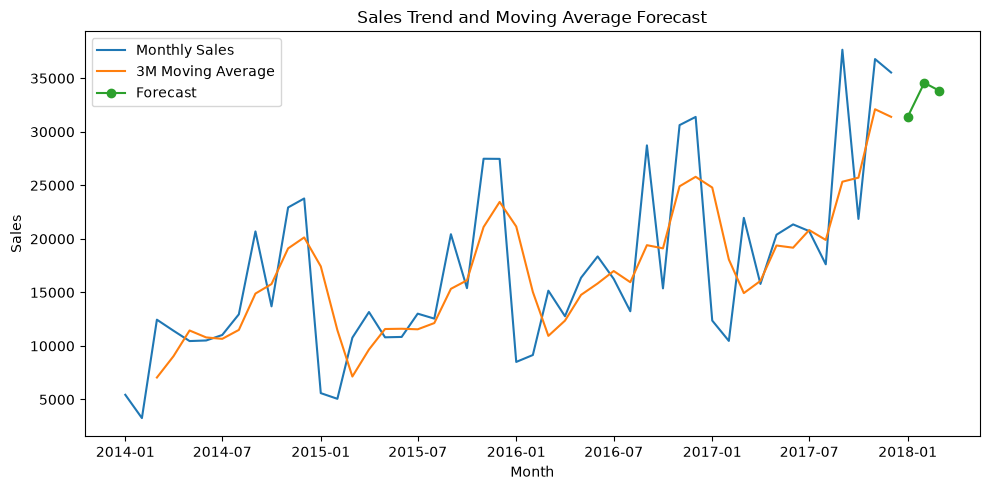

In [13]:
history = list(monthly['Sales'])
forecast=[]
for _ in range(3):
    f=float(np.mean(history[-3:])); forecast.append(f); history.append(f)
future_dates = pd.date_range(monthly['Order Date'].max()+pd.offsets.MonthBegin(1), periods=3, freq='MS')
forecast_df = pd.DataFrame({'Order Date':future_dates, 'Forecast Sales':forecast})
display(forecast_df)
plt.figure(figsize=(10,5))
plt.plot(monthly['Order Date'], monthly['Sales'], label='Monthly Sales')
plt.plot(monthly['Order Date'], monthly['Sales_3M_MA'], label='3M Moving Average')
plt.plot(forecast_df['Order Date'], forecast_df['Forecast Sales'], marker='o', label='Forecast')
plt.legend(); plt.title('Sales Trend and Moving Average Forecast'); plt.xlabel('Month'); plt.ylabel('Sales'); plt.tight_layout(); plt.show()


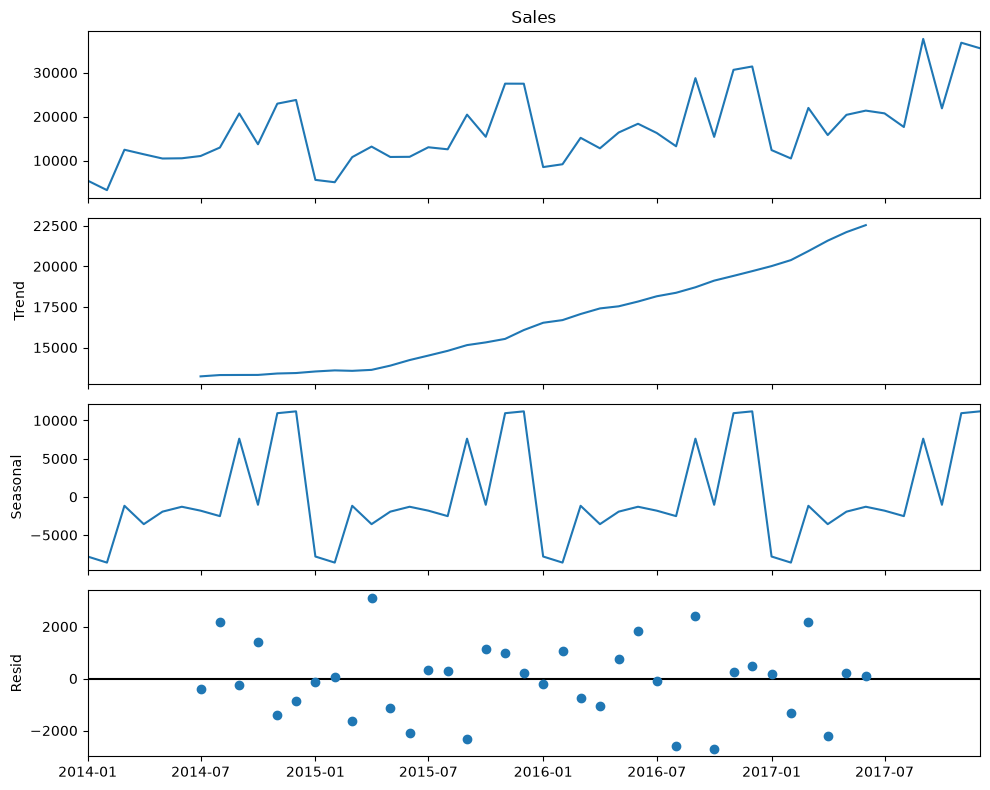

In [14]:
ts = monthly.set_index('Order Date')['Sales']
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot(); fig.set_size_inches(10,8); plt.tight_layout(); plt.show()


## 5. Customer Segmentation with K-Means (4 clusters)

In [15]:
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x:(reference_date-x.max()).days),
    Frequency=('Order ID','nunique'),
    Monetary=('Sales','sum')).reset_index()
scaler=StandardScaler()
X_scaled=scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
kmeans=KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster']=kmeans.fit_predict(X_scaled)
print('Silhouette score:', silhouette_score(X_scaled, rfm['Cluster']))
profile=rfm.groupby('Cluster').agg(Customers=('Customer ID','count'), Avg_Recency=('Recency','mean'), Avg_Frequency=('Frequency','mean'), Avg_Monetary=('Monetary','mean')).round(2)
display(profile)


Silhouette score: 0.3255058706963701


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,262,105.5,4.21,554.94
1,113,83.7,9.58,2150.37
2,306,86.3,7.02,1189.69
3,109,569.5,3.61,617.32


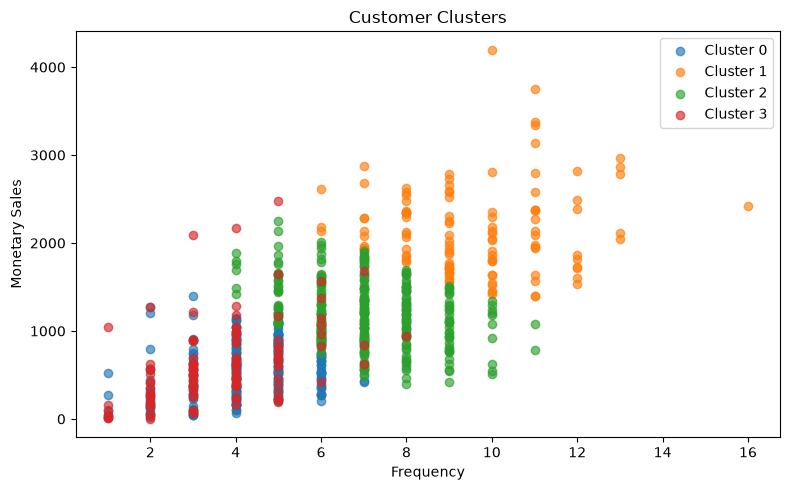

In [16]:
plt.figure(figsize=(8,5))
for c in sorted(rfm['Cluster'].unique()):
    part=rfm[rfm['Cluster']==c]
    plt.scatter(part['Frequency'], part['Monetary'], label=f'Cluster {c}', alpha=.65)
plt.xlabel('Frequency'); plt.ylabel('Monetary Sales'); plt.title('Customer Clusters'); plt.legend(); plt.tight_layout(); plt.show()


## 6. Basic Predictive Model – Linear Regression

In [17]:
features=['Quantity','Discount','Region','Category','Sub-Category','Segment','Ship Mode']
X=df[features]; y=df['Sales']
cat=[c for c in features if df[c].dtype=='object']; num=['Quantity','Discount']
pre=ColumnTransformer([('num','passthrough',num),('cat',OneHotEncoder(handle_unknown='ignore'),cat)])
model=Pipeline([('pre',pre),('reg',LinearRegression())])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)
model.fit(X_train,y_train); pred=model.predict(X_test)
print('R2:', r2_score(y_test,pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,pred)))
print('MAE:', mean_absolute_error(y_test,pred))


R2: 0.034664775997515274
RMSE: 113.11755922061548
MAE: 86.21479398945216


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Features
features = [
    'Quantity',
    'Discount',
    'Region',
    'Category',
    'Sub-Category',
    'Segment',
    'Ship Mode'
]

X = df[features]
y = df['Sales']

# Numeric and categorical columns
num = ['Quantity', 'Discount']

cat = [
    'Region',
    'Category',
    'Sub-Category',
    'Segment',
    'Ship Mode'
]

# Preprocessing
pre = ColumnTransformer([
    ('num', 'passthrough', num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
])

# Pipeline
model = Pipeline([
    ('pre', pre),
    ('reg', LinearRegression())
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# IMPORTANT: Fit model
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, pred))

R² Score: 0.3890102741773167
RMSE: 89.99282861968271
MAE: 62.16859609186253


In [24]:
# Get fitted encoder
ohe = model.named_steps['pre'].named_transformers_['cat']

# Feature names
names = num + list(
    ohe.get_feature_names_out(cat)
)

# Coefficients
coefs = model.named_steps['reg'].coef_

# Feature importance
importance = pd.DataFrame({
    'Feature': names,
    'Coefficient': coefs
})

importance['Abs_Coefficient'] = (
    importance['Coefficient'].abs()
)

importance = importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

display(importance.head(10))

,Feature,Coefficient,Abs_Coefficient
15,Sub-Category_Copiers,222.047126,222.047126
18,Sub-Category_Furnishings,-133.324562,133.324562
9,Sub-Category_Accessories,-118.461600,118.461600
7,Category_Office Supplies,-105.008880,105.008880
25,Sub-Category_Tables,76.560639,76.560639
8,Category_Technology,70.686541,70.686541
17,Sub-Category_Fasteners,-67.116393,67.116393
22,Sub-Category_Phones,-66.728087,66.728087
1,Discount,-64.729224,64.729224
23,Sub-Category_Storage,60.475429,60.475429


## 7. Business Recommendations

- Use VIP retention and premium cross-sell campaigns for high-value customers.
- Run win-back campaigns for customers with high recency values.
- Monitor discounts because discount is an important model feature and can affect sales relationships.
- Use the moving-average forecast as a baseline and compare it with ARIMA/Prophet for future iterations.
- Extend the model with cross-validation and a real business target such as churn when customer-status data becomes available.